In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from pandas.api.types import is_numeric_dtype

In [38]:
df = pd.read_excel("decision_data.xlsx")
df

,Days,Outlook,Temprature,Routine,Wear Jacket?
0,1,Sunny,Cold,Indoor,No
1,2,Cloudy,Cold,Indoor,Yes
2,3,Cloudy,Warm,Outdoor,No
3,4,Sunny,Cold,Outdoor,Yes
4,5,Cloudy,Cold,Outdoor,Yes
5,6,Sunny,Warm,Outdoor,No
6,7,Cloudy,Warm,Indoor,No
7,8,Sunny,Warm,Indoor,No


In [19]:
df.shape

(8, 5)

In [20]:
df.isna().sum()

Days            0
Outlook         0
Temprature      0
Routine         0
Wear Jacket?    0
dtype: int64

In [21]:
df.duplicated().sum()

0

In [22]:
df.describe()

,Days
count,8.00000
mean,4.50000
std,2.44949
min,1.00000
25%,2.75000
50%,4.50000
75%,6.25000
max,8.00000


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Days          8 non-null      int64 
 1   Outlook       8 non-null      object
 2   Temprature    8 non-null      object
 3   Routine       8 non-null      object
 4   Wear Jacket?  8 non-null      object
dtypes: int64(1), object(4)
memory usage: 452.0+ bytes


In [39]:
# Encoding
for col in df.columns:
    if col == 'Wear Jacket?':
        continue
    if is_numeric_dtype(df[col]):
        continue
    else:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])

In [40]:
df

,Days,Outlook,Temprature,Routine,Wear Jacket?
0,1,1,0,0,No
1,2,0,0,0,Yes
2,3,0,1,1,No
3,4,1,0,1,Yes
4,5,0,0,1,Yes
5,6,1,1,1,No
6,7,0,1,0,No
7,8,1,1,0,No


In [41]:
x = df.drop(['Days','Wear Jacket?'],axis = 1)
y = df['Wear Jacket?']

In [42]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.2, random_state=42)

In [43]:
print("XTRAIN Shape: ",xtrain.shape)
print('XTEST Shape: ',xtest.shape)
print('YTRAIN Shape: ',ytrain.shape)
print('YTEST Shape: ',ytest.shape)

XTRAIN Shape:  (6, 3)
XTEST Shape:  (2, 3)
YTRAIN Shape:  (6,)
YTEST Shape:  (2,)


In [44]:
dt = DecisionTreeClassifier()

In [45]:
dt.fit(xtrain,ytrain)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [46]:
predict = dt.predict(xtest)
predict

array(['No', 'No'], dtype=object)

In [47]:
dt.score(xtest,ytest)

0.5

In [48]:
dt.score(xtrain,ytrain)

1.0

[Text(0.6, 0.8333333333333334, 'x[1] <= 0.5\ngini = 0.444\nsamples = 6\nvalue = [4, 2]'),
 Text(0.4, 0.5, 'x[2] <= 0.5\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.7, 0.6666666666666667, '  False')]

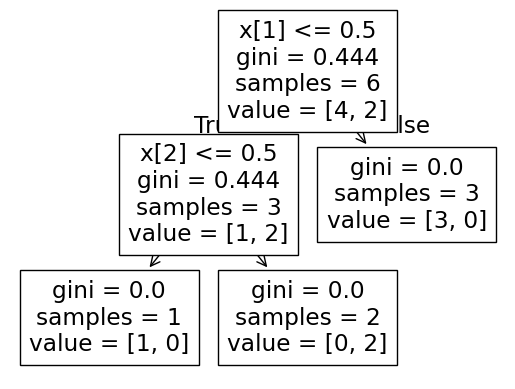

In [58]:
from sklearn import tree
tree.plot_tree(dt)

In [60]:
dt.classes_

array(['No', 'Yes'], dtype=object)

In [61]:
print(dt.classes_)

['No' 'Yes']


In [49]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

In [50]:
print('Accuracy Score: ', accuracy_score(ytest, predict))

Accuracy Score:  0.5


In [51]:
print('Classification Report: \n',classification_report(ytest,predict))

Classification Report: 
               precision    recall  f1-score   support

          No       0.50      1.00      0.67         1
         Yes       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



C:\Program Files\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Program Files\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Program Files\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


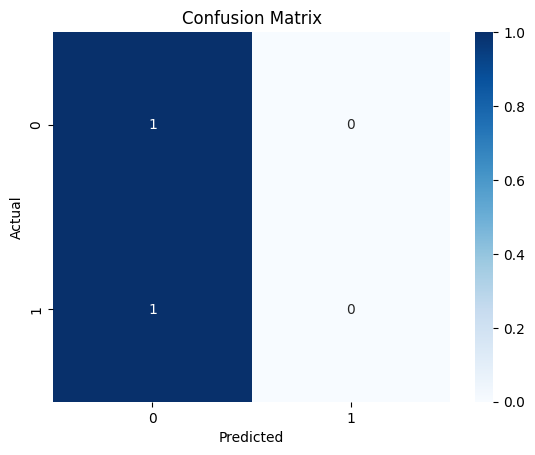

In [52]:
cm = confusion_matrix(ytest,predict)
sns.heatmap(cm , annot = True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

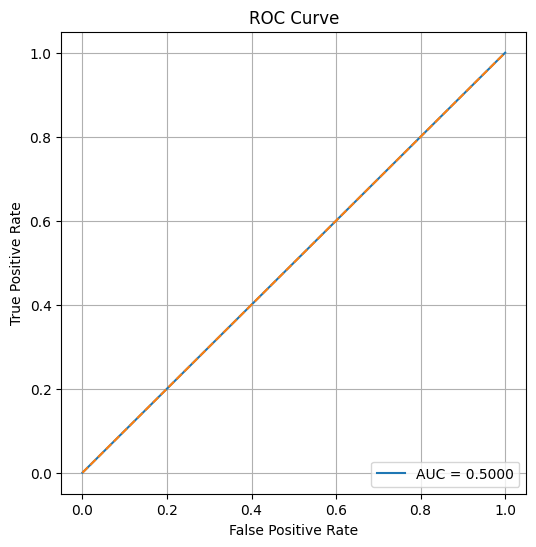

In [56]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probability of positive class
y_prob = dt.predict_proba(xtest)[:, 1]

# ROC values
fpr, tpr, threshold = roc_curve(ytest, y_prob,pos_label='Yes')

# AUC
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # Random classifier

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()